In [32]:
import pandas as pd
import numpy as np

def import_and_inspect_hotel_data(file_path):
    """
    Imports the Hotel Booking Demand dataset from a local path and conducts an initial structural review.
    """
    print("--- Step 0: Data Importation ---")
    try:
        # Dynamically loads the file path passed to the function
        df = pd.read_csv(file_path)
        print("Dataset loaded successfully from local machine!")
        print(f"Total Rows (Bookings): {df.shape[0]}")
        print(f"Total Columns (Features): {df.shape[1]}\n")
        
        # Display structural information about columns and memory usage
        print("--- Structural Summary (df.info()) ---")
        df.info()
        print("\n")
        
        return df
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return None

# FIXED: Your exact Windows folder path pointing directly to the file shown in your file explorer
# The 'r' before the string ensures Windows backslashes are read correctly by 


local_file_path = r"C:\Users\mukhe\OneDrive\Documents\Jobaaj_DA Projects\hotel_bookings.csv"

# Execute data loading step using your local file path
df = import_and_inspect_hotel_data(local_file_path)

--- Step 0: Data Importation ---
Dataset loaded successfully from local machine!
Total Rows (Bookings): 119390
Total Columns (Features): 32

--- Structural Summary (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                

In [33]:
# --- Step 1: Data Cleaning Pipeline ---

def clean_hotel_data(dataframe):
    """
    Handles missing values, drops duplicate records, and optimizes data formats.
    """
    # Create a copy to protect the original imported DataFrame
    cleaned_df = dataframe.copy()
    
    print("--- Starting Data Cleaning ---")
    
    # 1. Handle Missing Values
    # 'children': Missing values imply 0 children; fill with 0 and convert to integer
    cleaned_df['children'] = cleaned_df['children'].fillna(0).astype(int)
    
    # 'agent' & 'company': Missing values mean booked directly/personally; fill with 0
    cleaned_df['agent'] = cleaned_df['agent'].fillna(0).astype(int)
    cleaned_df['company'] = cleaned_df['company'].fillna(0).astype(int)
    
    # 'country': Fill missing values with a placeholder category 'Unknown'
    cleaned_df['country'] = cleaned_df['country'].fillna('Unknown')
    
    # 2. Convert Date Formats
    # Convert 'reservation_status_date' to a proper pandas datetime object
    cleaned_df['reservation_status_date'] = pd.to_datetime(cleaned_df['reservation_status_date'])
    
    # 3. Check and Remove Duplicate Entries
    initial_rows = cleaned_df.shape[0]
    duplicate_count = cleaned_df.duplicated().sum()
    
    if duplicate_count > 0:
        cleaned_df = cleaned_df.drop_duplicates()
        print(f"Removed {duplicate_count:,} duplicate rows.")
    else:
        print("No duplicate entries found.")
        
    final_rows = cleaned_df.shape[0]
    print(f"Cleaned dataset rows updated from {initial_rows:,} to {final_rows:,}.\n")
    
    return cleaned_df

# Execute the pipeline and overwrite 'df' with the pristine data
df = clean_hotel_data(df)

--- Starting Data Cleaning ---
Removed 31,994 duplicate rows.
Cleaned dataset rows updated from 119,390 to 87,396.



## Basic Level Topics

In [34]:
# --- Question 1: Average Lead Time ---

def calculate_average_lead_time(dataframe):
    """
    Calculates the average number of days between a guest's 
    booking date and their actual arrival date.
    """
    # Use pandas to calculate the arithmetic mean of the 'lead_time' column
    average_lead_time = dataframe['lead_time'].mean()
    
    print("--- Question 1: Operational Insights ---")
    print(f"The average lead time for bookings is: {average_lead_time:.2f} days\n")
    return average_lead_time

# Execute the function using your active 'df' variable
avg_lead_time = calculate_average_lead_time(df)

--- Question 1: Operational Insights ---
The average lead time for bookings is: 79.89 days



--- Question 2: Property Distribution ---
City Hotel: 53,428 bookings (61.13%)
Resort Hotel: 33,968 bookings (38.87%)


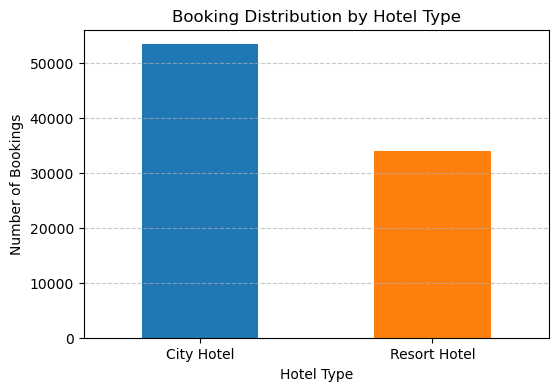

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def analyze_hotel_distribution(dataframe):
    """Counts reservations by hotel type and prints the relative distribution percentages."""
    # Count total records per hotel category
    counts = dataframe["hotel"].value_counts()

    # Calculate percentages using numpy
    percentages = (counts / np.sum(counts)) * 100

    print("--- Question 2: Property Distribution ---")
    for hotel_type, count in counts.items():
        pct = percentages[hotel_type]
        print(f"{hotel_type}: {count:,} bookings ({pct:.2f}%)")

    # Generate visual bar chart representation
    plt.figure(figsize=(6, 4))
    counts.plot(kind="bar", color=["#1f77b4", "#ff7f0e"])
    plt.title("Booking Distribution by Hotel Type")
    plt.xlabel("Hotel Type")
    plt.ylabel("Number of Bookings")
    plt.xticks(rotation=0)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

    return counts


# Execute analysis function
hotel_counts = analyze_hotel_distribution(df)

In [36]:
# --- Question 3: Total Canceled Bookings ---

def analyze_cancellations(dataframe):
    """
    Calculates total cancellations and the gross cancellation rate.
    """
    # Sum the binary flags (1 = Canceled, 0 = Checked Out / Kept)
    total_cancellations = dataframe['is_canceled'].sum()
    total_bookings = len(dataframe)
    
    # Calculate the percentage
    cancellation_rate = (total_cancellations / total_bookings) * 100
    
    print("--- Question 3: Cancellation Summary ---")
    print(f"Total Canceled Bookings: {total_cancellations:,}")
    print(f"Gross Cancellation Rate: {cancellation_rate:.2f}%\n")
    
    return total_cancellations, cancellation_rate

# Execute the calculation
canceled_count, gross_cancel_rate = analyze_cancellations(df)

--- Question 3: Cancellation Summary ---
Total Canceled Bookings: 24,025
Gross Cancellation Rate: 27.49%



In [37]:
# --- Question 4: Most Common Arrival Month ---

def analyze_most_common_arrival_month(dataframe):
    """
    Identifies the calendar month with the highest frequency of guest arrivals.
    """
    # Count the number of bookings for each month
    month_counts = dataframe['arrival_date_month'].value_counts()
    
    # Extract the mode (most common month) and its associated count
    most_common_month = month_counts.idxmax()
    highest_booking_count = month_counts.max()
    
    print("--- Question 4: Peak Arrival Windows ---")
    print(f"Most Common Arrival Month: {most_common_month}")
    print(f"Total Volume for Peak Month: {highest_booking_count:,} bookings\n")
    
    return most_common_month, month_counts

# Execute the calculation
peak_month, monthly_distribution = analyze_most_common_arrival_month(df)

--- Question 4: Peak Arrival Windows ---
Most Common Arrival Month: August
Total Volume for Peak Month: 11,257 bookings



In [38]:
# --- Question 5: Average Number of Special Requests ---

def calculate_average_special_requests(dataframe):
    """
    Computes the arithmetic mean of the 'total_of_special_requests' column.
    """
    # Calculate the average number of special requests using pandas
    average_requests = dataframe['total_of_special_requests'].mean()
    
    print("--- Question 5: Service Complexity ---")
    print(f"Average Special Requests per Booking: {average_requests:.2f} requests\n")
    return average_requests

# Execute the calculation
avg_special_requests = calculate_average_special_requests(df)

--- Question 5: Service Complexity ---
Average Special Requests per Booking: 0.70 requests



In [39]:
# --- Question 6: Primary Country of Origin ---

def analyze_top_booking_country(dataframe):
    """
    Identifies the country with the highest number of entries in the 'country' column.
    """
    # Count the number of bookings for each country
    country_counts = dataframe['country'].value_counts()
    
    # Extract the top country and its total booking volume
    top_country = country_counts.idxmax()
    top_country_volume = country_counts.max()
    
    print("--- Question 6: Geographic Demographics ---")
    print(f"Country with highest bookings: {top_country}")
    print(f"Total bookings from this country: {top_country_volume:,}\n")
    return top_country, country_counts

# Execute the calculation
primary_market, full_country_distribution = analyze_top_booking_country(df)

--- Question 6: Geographic Demographics ---
Country with highest bookings: PRT
Total bookings from this country: 27,453



In [40]:
# --- Question 7: Average Daily Rate (ADR) by Hotel Type ---


def analyze_adr_by_hotel(dataframe):
    """Groups the dataset by property type and calculates the average daily rate (ADR)."""
    # Group by the 'hotel' column and find the mean of the 'adr' column
    average_adr_by_hotel = dataframe.groupby("hotel")["adr"].mean()

    print("--- Question 7: Pricing & Revenue Management ---")
    for hotel_type, adr_value in average_adr_by_hotel.items():
        print(f"Average Daily Rate (ADR) for {hotel_type}: ${adr_value:.2f}")

    return average_adr_by_hotel


# Execute the calculation
property_adr = analyze_adr_by_hotel(df)

--- Question 7: Pricing & Revenue Management ---
Average Daily Rate (ADR) for City Hotel: $110.99
Average Daily Rate (ADR) for Resort Hotel: $99.03


In [41]:
# --- Question 8: Parking Space Requirements ---

def calculate_parking_demand(dataframe):
    """
    Calculates the percentage of total bookings that required 
    at least one car parking space.
    """
    # Filter for bookings where the required parking spaces are greater than 0
    parking_bookings = dataframe[dataframe['required_car_parking_spaces'] > 0]
    
    # Calculate the percentage
    total_bookings = len(dataframe)
    parking_percentage = (len(parking_bookings) / total_bookings) * 100
    
    print("--- Question 8: Infrastructure Demand ---")
    print(f"Bookings requiring parking: {len(parking_bookings):,}")
    print(f"Percentage of total guests: {parking_percentage:.2f}%\n")
    return parking_percentage

# Execute the calculation
parking_demand_pct = calculate_parking_demand(df)

--- Question 8: Infrastructure Demand ---
Bookings requiring parking: 7,313
Percentage of total guests: 8.37%



In [42]:
# --- Question 9: Stay Duration Patterns ---


def calculate_average_stay_duration(dataframe):
    """Computes the arithmetic mean for week nights and weekend nights independently."""
    # Calculate the average number of nights for weekdays and weekends
    avg_week_nights = dataframe["stays_in_week_nights"].mean()
    avg_weekend_nights = dataframe["stays_in_weekend_nights"].mean()
    avg_total_nights = (
        dataframe["stays_in_week_nights"] + dataframe["stays_in_weekend_nights"]
    ).mean()

    print("--- Question 9: Length of Stay (LOS) Patterns ---")
    print(f"Average Week Nights stayed: {avg_week_nights:.2f} nights")
    print(f"Average Weekend Nights stayed: {avg_weekend_nights:.2f} nights")
    print(f"Combined Average Length of Stay: {avg_total_nights:.2f} nights\n")

    return avg_week_nights, avg_weekend_nights


# Execute the calculation
week_avg, weekend_avg = calculate_average_stay_duration(df)

--- Question 9: Length of Stay (LOS) Patterns ---
Average Week Nights stayed: 2.63 nights
Average Weekend Nights stayed: 1.01 nights
Combined Average Length of Stay: 3.63 nights



In [43]:
# --- Question 10: Travel Agent Intermediation ---


def analyze_agent_bookings(dataframe):
    """Calculates how many bookings were made via third-party travel agencies."""
    # In Step 1 (Data Cleaning), missing agent IDs were filled with 0.
    # Therefore, any ID greater than 0 represents a third-party agent booking.
    agent_bookings = dataframe[dataframe["agent"] > 0]

    # Calculate absolute count and relative percentage
    total_agent_count = len(agent_bookings)
    total_bookings = len(dataframe)
    agent_percentage = (total_agent_count / total_bookings) * 100

    print("--- Question 10: Distribution Channels ---")
    print(f"Bookings mediated by Travel Agents: {total_agent_count:,}")
    print(f"Percentage of total bookings: {agent_percentage:.2f}%\n")

    return total_agent_count


# Execute the calculation
agent_booking_volume = analyze_agent_bookings(df)

--- Question 10: Distribution Channels ---
Bookings mediated by Travel Agents: 75,203
Percentage of total bookings: 86.05%



## Medium Level Topics

In [44]:
# --- Question 1: Cancellation Rate by Hotel Type ---


def analyze_cancellation_by_hotel(dataframe):
    """Groups the dataset by hotel type and calculates the mean cancellation rate."""
    # Grouping by 'hotel' and calculating the mean of 'is_canceled'
    # Multiplying by 100 converts the decimal fraction into a percentage
    cancellation_by_hotel = dataframe.groupby("hotel")["is_canceled"].mean() * 100

    print("--- Question 11: Attrition by Property Model ---")
    for hotel_type, cancel_rate in cancellation_by_hotel.items():
        print(f"Cancellation Rate for {hotel_type}: {cancel_rate:.2f}%")

    return cancellation_by_hotel


# Execute the calculation
hotel_cancel_rates = analyze_cancellation_by_hotel(df)

--- Question 11: Attrition by Property Model ---
Cancellation Rate for City Hotel: 30.04%
Cancellation Rate for Resort Hotel: 23.48%


In [45]:
# --- Question 2: Average ADR per Market Segment ---


def analyze_adr_per_market_segment(dataframe):
    """Groups the data by market segment and calculates the average daily rate (ADR)."""
    # Group by market segment and calculate the mean of the ADR column
    adr_per_segment = dataframe.groupby("market_segment")["adr"].mean()

    # Sort in descending order to easily see the highest-yielding customer segments
    adr_per_segment = adr_per_segment.sort_values(ascending=False)

    print("--- Question 12: Segment Financial Yield ---")
    for segment, adr_value in adr_per_segment.items():
        print(f"Market Segment [{segment:12}]: Average ADR = ${adr_value:.2f}")

    return adr_per_segment


# Execute the calculation
segment_adr_performance = analyze_adr_per_market_segment(df)

--- Question 12: Segment Financial Yield ---
Market Segment [Online TA   ]: Average ADR = $118.17
Market Segment [Direct      ]: Average ADR = $116.58
Market Segment [Aviation    ]: Average ADR = $100.17
Market Segment [Offline TA/TO]: Average ADR = $81.76
Market Segment [Groups      ]: Average ADR = $74.86
Market Segment [Corporate   ]: Average ADR = $68.15
Market Segment [Undefined   ]: Average ADR = $15.00
Market Segment [Complementary]: Average ADR = $3.05


In [46]:
# --- Question 3: Lead Time vs. Cancellation Rate ---


def analyze_lead_time_cancellation(dataframe):
    """Groups lead times into 30-day blocks and calculates the cancellation rate for each."""
    # Define 30-day interval blocks up to the maximum lead time
    max_time = dataframe["lead_time"].max()
    bin_edges = np.arange(0, max_time + 30, 30)

    # Generate readable string labels for each bin block
    bin_labels = [
        f"{bin_edges[i]}-{bin_edges[i+1]}" for i in range(len(bin_edges) - 1)
    ]

    # Segment the data into the defined bins
    binned_data = pd.cut(
        dataframe["lead_time"],
        bins=bin_edges,
        labels=bin_labels,
        include_lowest=True,
    )

    # Group by the new bins and calculate the average cancellation percentage
    cancellation_by_lead_time = (
        dataframe.groupby(binned_data, observed=False)["is_canceled"].mean()
        * 100
    )

    print("--- Question 13: Lead Time Risk Horizon ---")
    # Display the first 6 ranges for immediate clean inspection
    for block, rate in cancellation_by_lead_time.head(6).items():
        print(
            f"Lead Time Window [{block:7} Days]: Cancellation Rate = {rate:.2f}%"
        )

    return cancellation_by_lead_time


# Execute the analysis
lead_time_matrix = analyze_lead_time_cancellation(df)

--- Question 13: Lead Time Risk Horizon ---
Lead Time Window [0-30    Days]: Cancellation Rate = 16.42%
Lead Time Window [30-60   Days]: Cancellation Rate = 31.62%
Lead Time Window [60-90   Days]: Cancellation Rate = 32.56%
Lead Time Window [90-120  Days]: Cancellation Rate = 34.82%
Lead Time Window [120-150 Days]: Cancellation Rate = 35.44%
Lead Time Window [150-180 Days]: Cancellation Rate = 34.72%


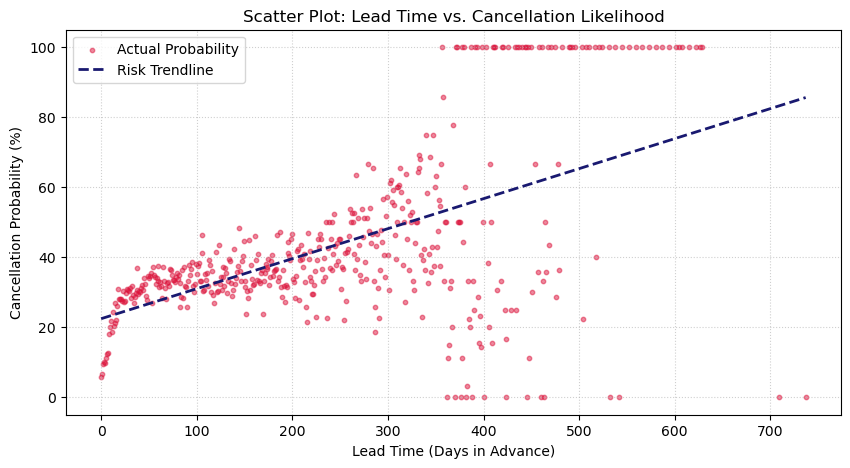

In [47]:
import matplotlib.pyplot as plt

# 1. Group by each distinct lead time day and calculate the cancellation percentage
cancellation_likelihood = df.groupby('lead_time')['is_canceled'].mean() * 100

# 2. Generate the scatter plot visualization
plt.figure(figsize=(10, 5))
plt.scatter(cancellation_likelihood.index, cancellation_likelihood.values, 
            alpha=0.5, color='crimson', s=10, label='Actual Probability')

# 3. Fit a trendline to reveal the underlying direction clearly
x = cancellation_likelihood.index
y = cancellation_likelihood.values
if len(x) > 1:
    m, c = np.polyfit(x, y, 1)
    plt.plot(x, m*x + c, color='midnightblue', linestyle='--', linewidth=2, label='Risk Trendline')

plt.title('Scatter Plot: Lead Time vs. Cancellation Likelihood')
plt.xlabel('Lead Time (Days in Advance)')
plt.ylabel('Cancellation Probability (%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

In [48]:
# --- Question 4: Top Distribution Channels ---


def analyze_top_distribution_channel(dataframe):
    """Counts the bookings for each distribution channel and identifies the top one."""
    # Count the total number of bookings for each channel option
    channel_counts = dataframe["distribution_channel"].value_counts()

    # Identify the top-performing channel and its absolute volume
    top_channel = channel_counts.idxmax()
    top_channel_volume = channel_counts.max()

    # Calculate total bookings across all channels to find percentages
    total_bookings = channel_counts.sum()

    print("--- Question 14: Distribution Channel Volume ---")
    for channel, count in channel_counts.items():
        pct = (count / total_bookings) * 100
        print(f"Channel [{channel:9}]: {count:7,} bookings ({pct:.2f}%)")

    print(
        f"\nWinner: The channel with the highest number of bookings is '{top_channel}' with {top_channel_volume:,} reservations.\n"
    )

    return channel_counts


# Execute the calculation
distribution_summary = analyze_top_distribution_channel(df)

--- Question 14: Distribution Channel Volume ---
Channel [TA/TO    ]:  69,141 bookings (79.11%)
Channel [Direct   ]:  12,988 bookings (14.86%)
Channel [Corporate]:   5,081 bookings (5.81%)
Channel [GDS      ]:     181 bookings (0.21%)
Channel [Undefined]:       5 bookings (0.01%)

Winner: The channel with the highest number of bookings is 'TA/TO' with 69,141 reservations.



In [49]:
# --- Question 5: Average Previous Cancellations by Hotel Type ---


def analyze_previous_cancellations(dataframe):
    """Groups data by hotel type and calculates the mean of previous customer cancellations."""
    # Group by the 'hotel' type and calculate the mean of 'previous_cancellations'
    avg_prev_cancellations = dataframe.groupby("hotel")[
        "previous_cancellations"
    ].mean()

    print("--- Question 15: Historical Attrition Risk ---")
    for hotel_type, mean_val in avg_prev_cancellations.items():
        print(
            f"Average Previous Cancellations for {hotel_type}: {mean_val:.4f} per booking"
        )

    return avg_prev_cancellations


# Execute the calculation
previous_cancel_profile = analyze_previous_cancellations(df)

--- Question 15: Historical Attrition Risk ---
Average Previous Cancellations for City Hotel: 0.0358 per booking
Average Previous Cancellations for Resort Hotel: 0.0220 per booking


--- Question 16: Annual Financial Trajectory ---
Calendar Year 2015: Average ADR = $92.16
Calendar Year 2016: Average ADR = $101.54
Calendar Year 2017: Average ADR = $118.71


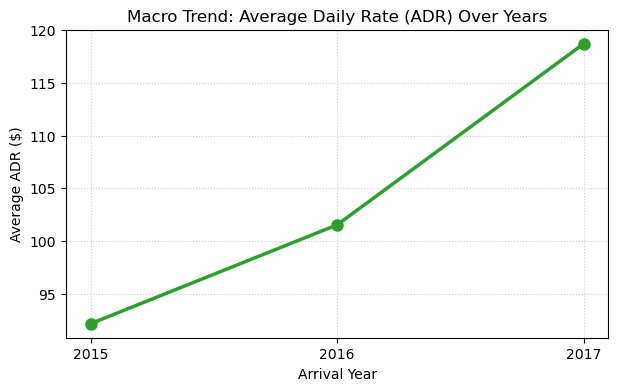

In [50]:
import matplotlib.pyplot as plt

# --- Question 6: Macro ADR Trend Line ---


def analyze_adr_trend_over_years(dataframe):
    """Calculates the average daily rate (ADR) per calendar year and plots the trend line."""
    # Group by arrival year and find the mean ADR
    yearly_adr = dataframe.groupby("arrival_date_year")["adr"].mean()

    print("--- Question 16: Annual Financial Trajectory ---")
    for year, adr_value in yearly_adr.items():
        print(f"Calendar Year {year}: Average ADR = ${adr_value:.2f}")

    # Generate the line plot visualization
    plt.figure(figsize=(7, 4))
    plt.plot(
        yearly_adr.index,
        yearly_adr.values,
        marker="o",
        linewidth=2.5,
        color="#2ca02c",
        markersize=8,
    )

    # Clean up formatting for categorical years
    plt.title("Macro Trend: Average Daily Rate (ADR) Over Years")
    plt.xlabel("Arrival Year")
    plt.ylabel("Average ADR ($)")
    plt.xticks(yearly_adr.index)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.show()

    return yearly_adr


# Execute the trend calculation
annual_adr_trend = analyze_adr_trend_over_years(df)

In [51]:
# --- Question 7: Most Profitable Calendar Month ---


def analyze_highest_revenue_month(dataframe):
    """Calculates gross revenue for kept bookings and finds the most profitable month."""
    # 1. Filter out canceled reservations to isolate actual realized revenue
    actual_stays = dataframe[dataframe["is_canceled"] == 0].copy()

    # 2. Calculate total nights stayed for each reservation
    total_nights = (
        actual_stays["stays_in_week_nights"]
        + actual_stays["stays_in_weekend_nights"]
    )

    # 3. Calculate gross booking revenue
    actual_stays["booking_revenue"] = total_nights * actual_stays["adr"]

    # 4. Aggregate revenue by arrival month
    monthly_revenue = actual_stays.groupby("arrival_date_month")[
        "booking_revenue"
    ].sum()

    # Sort in descending order to find the top earner
    monthly_revenue_sorted = monthly_revenue.sort_values(ascending=False)

    print("--- Question 17: Revenue Performance Matrix ---")
    for month, rev in monthly_revenue_sorted.items():
        print(f"Month [{month:9}]: Total Realized Revenue = ${rev:,.2f}")

    top_month = monthly_revenue_sorted.idxmax()
    top_month_value = monthly_revenue_sorted.max()

    print(
        f"\nWinner: '{top_month}' generated the highest revenue with ${top_month_value:,.2f}\n"
    )

    return monthly_revenue_sorted


# Execute the calculation
revenue_by_month = analyze_highest_revenue_month(df)

--- Question 17: Revenue Performance Matrix ---
Month [August   ]: Total Realized Revenue = $4,608,288.90
Month [July     ]: Total Realized Revenue = $3,799,350.53
Month [June     ]: Total Realized Revenue = $2,296,399.43
Month [May      ]: Total Realized Revenue = $2,060,619.53
Month [September]: Total Realized Revenue = $1,970,554.65
Month [April    ]: Total Realized Revenue = $1,805,375.46
Month [October  ]: Total Realized Revenue = $1,476,094.71
Month [March    ]: Total Realized Revenue = $1,416,047.15
Month [February ]: Total Realized Revenue = $1,025,077.03
Month [December ]: Total Realized Revenue = $920,036.12
Month [November ]: Total Realized Revenue = $893,645.61
Month [January  ]: Total Realized Revenue = $705,407.21

Winner: 'August' generated the highest revenue with $4,608,288.90



In [52]:
# --- Question 8: Impact of Special Requests on ADR ---


def analyze_special_requests_impact(dataframe):
    """Groups bookings by total special requests and computes the average daily rate (ADR)."""
    # Group by the count of special requests and calculate the mean ADR
    adr_by_requests = dataframe.groupby("total_of_special_requests")["adr"].mean()
    volume_by_requests = dataframe.groupby("total_of_special_requests")[
        "adr"
    ].count()

    print("--- Question 18: Custom Request Pricing Impact ---")
    for requests_count, mean_adr in adr_by_requests.items():
        vol = volume_by_requests[requests_count]
        print(
            f"Special Requests: {requests_count} | Average ADR = ${mean_adr:6.2f} ({vol:6,} bookings)"
        )

    return adr_by_requests


# Execute the calculation
request_pricing_matrix = analyze_special_requests_impact(df)

--- Question 18: Custom Request Pricing Impact ---
Special Requests: 0 | Average ADR = $ 99.67 (43,894 bookings)
Special Requests: 1 | Average ADR = $109.65 (29,017 bookings)
Special Requests: 2 | Average ADR = $118.57 (11,812 bookings)
Special Requests: 3 | Average ADR = $125.07 ( 2,317 bookings)
Special Requests: 4 | Average ADR = $131.09 (   320 bookings)
Special Requests: 5 | Average ADR = $129.98 (    36 bookings)


In [53]:
# --- Question 9: Stay Duration (Repeated vs. New Guests) ---


def analyze_stay_duration_by_loyalty(dataframe):
    """Calculates and compares the average total length of stay for new vs.

    repeated guests.
    """
    analysis_df = dataframe.copy()

    # 1. Calculate total nights stayed for every single booking record
    analysis_df["total_nights_stayed"] = (
        analysis_df["stays_in_week_nights"]
        + analysis_df["stays_in_weekend_nights"]
    )

    # 2. Group by the loyalty metric flag (0 = New Guest, 1 = Repeated Guest)
    loyalty_groups = analysis_df.groupby("is_repeated_guest")[
        "total_nights_stayed"
    ].mean()

    print("--- Question 19: Behavioral Footprint by Loyalty ---")
    print(
        f"Average Nights Stayed by New Guests (0)     : {loyalty_groups[0]:.2f} nights"
    )
    print(
        f"Average Nights Stayed by Repeated Guests (1): {loyalty_groups[1]:.2f} nights\n"
    )

    return loyalty_groups


# Execute the calculation
loyalty_stay_comparison = analyze_stay_duration_by_loyalty(df)

--- Question 19: Behavioral Footprint by Loyalty ---
Average Nights Stayed by New Guests (0)     : 3.70 nights
Average Nights Stayed by Repeated Guests (1): 1.93 nights



In [54]:
# --- Question 10: Most Popular Reserved Room Type ---


def analyze_reserved_room_types(dataframe):
    """Counts booking volume per room type code and identifies the absolute mode."""
    # Run a frequency count on reserved room types
    room_counts = dataframe["reserved_room_type"].value_counts()

    # Isolate the winner and its volume
    top_room = room_counts.idxmax()
    top_room_volume = room_counts.max()

    print("--- Question 20: Inventory Demand Rankings ---")
    for room_code, count in room_counts.items():
        print(f"Room Configuration Category [{room_code}]: {count:7,} bookings")

    print(
        f"\nWinner: Room Type '{top_room}' is the most popular with {top_room_volume:,} bookings.\n"
    )
    return room_counts


# Execute the calculation
room_demand_profile = analyze_reserved_room_types(df)

--- Question 20: Inventory Demand Rankings ---
Room Configuration Category [A]:  56,552 bookings
Room Configuration Category [D]:  17,398 bookings
Room Configuration Category [E]:   6,049 bookings
Room Configuration Category [F]:   2,823 bookings
Room Configuration Category [G]:   2,052 bookings
Room Configuration Category [B]:     999 bookings
Room Configuration Category [C]:     915 bookings
Room Configuration Category [H]:     596 bookings
Room Configuration Category [L]:       6 bookings
Room Configuration Category [P]:       6 bookings

Winner: Room Type 'A' is the most popular with 56,552 bookings.



## Advanced Level Topics

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Question 1: Advanced Logistic Regression Model ---


def analyze_cancellation_drivers(dataframe):
    """Builds a logistic regression model to isolate significant features driving cancellations."""
    print("--- Question 21: Statistical Risk Modeling ---")

    # 1. Define predictive features (X) and target flag variable (y)
    features = [
        "lead_time",
        "previous_cancellations",
        "booking_changes",
        "total_of_special_requests",
    ]
    X = dataframe[features]
    y = dataframe["is_canceled"]

    # 2. Split dataset into training sets (80%) and testing validation sets (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 3. Standardize feature scales to allow accurate comparison of coefficient values
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 4. Train the Logistic Regression classifier
    model = LogisticRegression(random_state=42)
    model.fit(X_train_scaled, y_train)

    # 5. Extract and display feature coefficients (weights)
    print(f"Model Baseline Accuracy Score: {model.score(X_test_scaled, y_test)*100:.2f}%\n")
    print("Feature Importance Breakdown (Impact Weights):")

    coefficients = model.coef_[0]
    feature_impact = pd.DataFrame(
        {"Feature": features, "Coefficient (Weight)": coefficients}
    ).sort_values(by="Coefficient (Weight)", ascending=False)

    for _, row in feature_impact.iterrows():
        feat = row["Feature"]
        coef = row["Coefficient (Weight)"]
        direction = "INCREASES" if coef > 0 else "DECREASES"
        print(f" -> [{feat:25}]: Weight = {coef:6.3f} | ({direction} cancellation risk)")

    return model, feature_impact


# Execute statistical modeling
cancellation_model, operational_weights = analyze_cancellation_drivers(df)

--- Question 21: Statistical Risk Modeling ---
Model Baseline Accuracy Score: 72.64%

Feature Importance Breakdown (Impact Weights):
 -> [lead_time                ]: Weight =  0.434 | (INCREASES cancellation risk)
 -> [previous_cancellations   ]: Weight =  0.157 | (INCREASES cancellation risk)
 -> [total_of_special_requests]: Weight = -0.321 | (DECREASES cancellation risk)
 -> [booking_changes          ]: Weight = -0.375 | (DECREASES cancellation risk)


In [56]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

def perform_robust_cancellation_regression(dataframe):
    """
    Executes a complete Logistic Regression analysis including categorical feature encoding,
    feature scaling, model training, performance evaluation, and coefficient interpretation.
    """
    print("=== Advanced Logistic Regression Analysis ===\n")
    
    # 1. Isolate the target variable and choose a comprehensive mix of relevant features
    target = 'is_canceled'
    
    numeric_features = [
        'lead_time', 
        'booking_changes', 
        'total_of_special_requests', 
        'previous_cancellations',
        'stays_in_week_nights',
        'stays_in_weekend_nights'
    ]
    
    categorical_features = [
        'deposit_type', 
        'market_segment'
    ]
    
    # Filter dataset down to selected workspace features
    working_df = dataframe[numeric_features + categorical_features + [target]].copy()
    
    # 2. Process Categorical Data via One-Hot Encoding (Creates binary flag columns)
    # drop_first=True avoids multi-collinearity (dummy variable trap)
    encoded_df = pd.get_dummies(working_df, columns=categorical_features, drop_first=True)
    
    # 3. Separate predictors (X) from the target outcome variable (y)
    X = encoded_df.drop(columns=[target])
    y = encoded_df[target]
    
    # 4. Partition data into Train (80%) and Test (20%) sets using stratified splitting
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 5. Standardize numerical features so columns with larger absolute numbers (e.g. lead_time)
    # do not artificially dominate columns with smaller numerical ranges (e.g. booking_changes)
    scaler = StandardScaler()
    
    # Identify all columns resulting from encoding to apply scaling safely
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 6. Instantiate and train the Logistic Regression Classifier
    # max_iter is increased to ensure model convergence
    log_reg = LogisticRegression(max_iter=1000, random_state=42)
    log_reg.fit(X_train_scaled, y_train)
    
    # 7. Generate model predictions against the unseen test partition
    y_pred = log_reg.predict(X_test_scaled)
    
    # 8. Report Performance Metrics
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Overall Model Accuracy: {accuracy * 100:.2f}%\n")
    
    print("--- Detailed Classification Report ---")
    print(classification_report(y_test, y_pred))
    
    print("--- Confusion Matrix ---")
    cm = confusion_matrix(y_test, y_pred)
    print(f"True Negatives (Kept correctly predicted):  {cm[0][0]:,}")
    print(f"False Positives (Predicted cancel, but kept): {cm[0][1]:,}")
    print(f"False Negatives (Predicted kept, but canceled): {cm[1][0]:,}")
    print(f"True Positives (Canceled correctly predicted): {cm[1][1]:,}\n")
    
    # 9. Extract and rank individual operational feature weights (Coefficients)
    importance_df = pd.DataFrame({
        'Feature_Name': X.columns,
        'Coefficient_Weight': log_reg.coef_[0]
    })
    
    # Sort features by absolute impact magnitude to find real operational drivers
    importance_df['Absolute_Impact'] = importance_df['Coefficient_Weight'].abs()
    ranked_drivers = importance_df.sort_values(by='Absolute_Impact', ascending=False)
    
    print("--- Ranked Strategic Attrition Drivers (Coefficients) ---")
    for _, row in ranked_drivers.iterrows():
        feat = row['Feature_Name']
        coef = row['Coefficient_Weight']
        risk_direction = "🔴 INCREASES risk" if coef > 0 else "🟢 DECREASES risk"
        print(f"Variable: {feat:35} | Weight: {coef:6.3f} | {risk_direction}")
        
    return log_reg, ranked_drivers

# Run the complete analysis workflow on your live dataframe variable
cancellation_model, feature_rankings = perform_robust_cancellation_regression(df)

=== Advanced Logistic Regression Analysis ===

Overall Model Accuracy: 76.68%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.95      0.85     12675
           1       0.67      0.29      0.41      4805

    accuracy                           0.77     17480
   macro avg       0.73      0.62      0.63     17480
weighted avg       0.75      0.77      0.73     17480

--- Confusion Matrix ---
True Negatives (Kept correctly predicted):  11,994
False Positives (Predicted cancel, but kept): 681
False Negatives (Predicted kept, but canceled): 3,395
True Positives (Canceled correctly predicted): 1,410

--- Ranked Strategic Attrition Drivers (Coefficients) ---
Variable: total_of_special_requests           | Weight: -0.563 | 🟢 DECREASES risk
Variable: market_segment_Online TA            | Weight:  0.471 | 🔴 INCREASES risk
Variable: deposit_type_Non Refund             | Weight:  0.442 | 🔴 INCREASES risk
Variable: lead_ti

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# --- Question 2: Robust Multiple Linear Regression for ADR ---

def analyze_guest_composition_impact_on_adr(dataframe):
    """
    Performs a multiple linear regression to evaluate how the number of
    adults, children, and babies predicts the Average Daily Rate (ADR).
    Cleans structural null entries dynamically before model fitting.
    """
    print("=== Advanced Multiple Linear Regression Analysis ===\n")
    
    predictors = ['adults', 'children', 'babies']
    target = 'adr'
    
    # 1. Create an insulated copy of the dataset
    clean_reg_df = dataframe.copy()
    
    # 2. Drop rows where the target target ('adr') is completely missing
    clean_reg_df = clean_reg_df.dropna(subset=[target])
    
    # 3. Handle missing values in feature columns internally to prevent ValueError crashes
    for col in predictors:
        clean_reg_df[col] = clean_reg_df[col].fillna(0).astype(int)
    
    # 4. Filter data to strip pricing anomalies (complimentary rooms or extreme values)
    clean_reg_df = clean_reg_df[(clean_reg_df[target] > 0) & (clean_reg_df[target] < 1000)]
    
    # 5. Separate features from the target metric
    X = clean_reg_df[predictors]
    y = clean_reg_df[target]
    
    # 6. Split into training (80%) and testing validation sets (20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 7. Initialize and fit the Multiple Linear Regression model
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    
    # 8. Generate model predictions against validation test data
    y_pred = lr_model.predict(X_test)
    
    # 9. Output performance diagnostics
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"Model Intercept (Base Rate Baseline): ${lr_model.intercept_:.2f}")
    print(f"Mean Absolute Error (MAE): ${mae:.2f}")
    print(f"R-squared Score (Variance Explained): {r2:.4f}\n")
    
    # 10. Extract individual feature impacts (Coefficients)
    print("Marginal Pricing Impact per Guest Type:")
    coefficients = lr_model.coef_
    for feature, coef in zip(predictors, coefficients):
        print(f" -> Each additional [{feature:8}]: Increases room ADR by ${coef:.2f} per night")
        
    return lr_model, coefficients

# Execute the regression pipeline safely
adr_regression_model, guest_coefficients = analyze_guest_composition_impact_on_adr(df)

=== Advanced Multiple Linear Regression Analysis ===

Model Intercept (Base Rate Baseline): $43.82
Mean Absolute Error (MAE): $34.01
R-squared Score (Variance Explained): 0.2265

Marginal Pricing Impact per Guest Type:
 -> Each additional [adults  ]: Increases room ADR by $31.40 per night
 -> Each additional [children]: Increases room ADR by $38.49 per night
 -> Each additional [babies  ]: Increases room ADR by $6.54 per night


In [58]:
import numpy as np
import pandas as pd

# --- Question 3: Impact of Booking Changes on Special Requests ---

def analyze_changes_vs_special_requests(dataframe):
    """
    Computes the correlation coefficients between booking modifications 
    and guest service requests to assess behavioral alignment.
    """
    print("=== Advanced Operational Correlation Analysis ===\n")
    
    # 1. Calculate standard Pearson correlation (evaluates linear trends)
    pearson_corr = dataframe['booking_changes'].corr(dataframe['total_of_special_requests'], method='pearson')
    
    # 2. Calculate Spearman rank correlation (evaluates monotonic or skewed trends)
    spearman_corr = dataframe['booking_changes'].corr(dataframe['total_of_special_requests'], method='spearman')
    
    print("Correlation Strengths Matrix:")
    print(f" -> Pearson Linear Correlation  : {pearson_corr:7.4f}")
    print(f" -> Spearman Rank Correlation   : {spearman_corr:7.4f}\n")
    
    # 3. Descriptive slice: Look at the mean requests grouped by number of changes
    print("Descriptive Assessment Table:")
    summary_table = dataframe.groupby('booking_changes')['total_of_special_requests'].agg(['mean', 'count']).head(5)
    print(summary_table.to_string())
    
    # 4. Interpret structural business metrics
    print("\n--- Operational Strategy Context ---")
    if pearson_corr > 0.1:
        print("Insight: Positive alignment found. Guests who modify bookings are highly engaged and make more requests.")
    elif pearson_corr < -0.1:
        print("Insight: Negative alignment found. Booking changes drop guest enthusiasm, leading to fewer requests.")
    else:
        print("Insight: Weak or near-neutral relationship. Booking modifications do not systemically dictate special requests.")
        
    return pearson_corr

# Execute metric correlation steps
correlation_score = analyze_changes_vs_special_requests(df)


=== Advanced Operational Correlation Analysis ===

Correlation Strengths Matrix:
 -> Pearson Linear Correlation  :  0.0161
 -> Spearman Rank Correlation   : -0.0049

Descriptive Assessment Table:
                     mean  count
booking_changes                 
0                0.696562  71494
1                0.681985  10902
2                0.737172   3508
3                0.826286    875
4                0.820225    356

--- Operational Strategy Context ---
Insight: Weak or near-neutral relationship. Booking modifications do not systemically dictate special requests.


In [59]:
# --- Question 4: Seasonal Impact on Booking Cancellations ---


def analyze_seasonal_cancellation_patterns(dataframe):
    """Calculates the cancellation rate for each month to uncover seasonal risk patterns."""
    print("=== Advanced Seasonal Attrition Analysis ===\n")

    # 1. Group by arrival month and calculate the average cancellation rate
    # Multiplying by 100 turns the fraction into a clear percentage
    seasonal_cancellations = (
        dataframe.groupby("arrival_date_month")["is_canceled"].mean() * 100
    )

    # Count total reservation volumes per month to track overall visibility
    monthly_volumes = dataframe.groupby("arrival_date_month")[
        "is_canceled"
    ].count()

    # 2. Combine metrics into a single summary table
    seasonal_summary = pd.DataFrame(
        {
            "Cancellation Rate (%)": seasonal_cancellations,
            "Total Bookings Received": monthly_volumes,
        }
    )

    # 3. Sort chronologically by calendar order for smooth review
    calendar_order = [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December",
    ]
    # Filter the order to match only the months present in your dataset
    existing_months = [m for m in calendar_order if m in seasonal_summary.index]
    seasonal_summary = seasonal_summary.reindex(existing_months)

    print("Monthly Cancellation Risk Breakdown:")
    for month, row in seasonal_summary.iterrows():
        print(
            f"Month: {month:10} | Risk Rate: {row['Cancellation Rate (%)']:6.2f}% | Volume: {int(row['Total Bookings Received']):,}"
        )

    # Isolate the highest-risk month
    peak_risk_month = seasonal_summary["Cancellation Rate (%)"].idxmax()
    peak_risk_value = seasonal_summary["Cancellation Rate (%)"].max()
    print(
        f"\nPeak Vulnerability Window: '{peak_risk_month}' shows the highest cancellation rate at {peak_risk_value:.2f}%.\n"
    )

    return seasonal_summary


# Execute the seasonal analysis pipeline
seasonal_risk_report = analyze_seasonal_cancellation_patterns(df)

=== Advanced Seasonal Attrition Analysis ===

Monthly Cancellation Risk Breakdown:
Month: January    | Risk Rate:  22.12% | Volume: 4,693
Month: February   | Risk Rate:  23.20% | Volume: 6,098
Month: March      | Risk Rate:  24.36% | Volume: 7,513
Month: April      | Risk Rate:  30.46% | Volume: 7,908
Month: May        | Risk Rate:  29.23% | Volume: 8,355
Month: June       | Risk Rate:  30.32% | Volume: 7,765
Month: July       | Risk Rate:  31.80% | Volume: 10,057
Month: August     | Risk Rate:  32.18% | Volume: 11,257
Month: September  | Risk Rate:  24.54% | Volume: 6,690
Month: October    | Risk Rate:  23.68% | Volume: 6,934
Month: November   | Risk Rate:  21.10% | Volume: 4,995
Month: December   | Risk Rate:  26.86% | Volume: 5,131

Peak Vulnerability Window: 'August' shows the highest cancellation rate at 32.18%.



=== Advanced Market Segment Lead Time Analysis ===

Lead Time Statistical Summary Table:
                count  median    mean     std
market_segment                               
Aviation          227     3.0    4.28    4.50
Complementary     702     3.0   13.64   32.36
Corporate        4212     5.0   16.25   31.74
Direct          11804    15.0   48.83   69.52
Groups           4942   114.0  147.61  129.79
Offline TA/TO   13889    82.0  106.05   95.55
Online TA       51618    55.0   79.90   77.51
Undefined           2     1.5    1.50    0.71




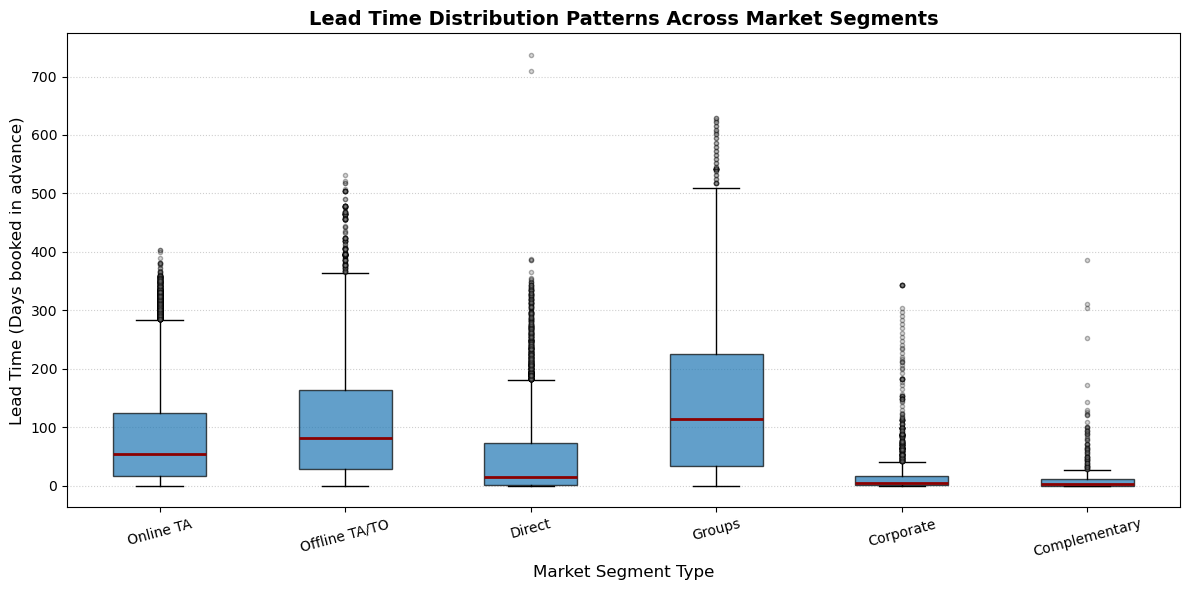

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Question 5: Lead Time Distribution Across Market Segments ---


def analyze_lead_time_by_segment(dataframe):
    """Generates a detailed summary and box plot distribution of booking lead times

    segmented by market channel.
    """
    print("=== Advanced Market Segment Lead Time Analysis ===\n")

    # 1. Calculate statistical summaries for each market segment using pandas
    segments_summary = dataframe.groupby("market_segment")["lead_time"].agg(
        ["count", "median", "mean", "std"]
    )
    print("Lead Time Statistical Summary Table:")
    print(segments_summary.round(2).to_string())
    print("\n")

    # 2. Filter data down to segments with major volume to keep the graph clean
    # Excludes sparse or empty placeholder rows if any exist
    valid_segments = dataframe["market_segment"].value_counts().index[:6]
    plot_df = dataframe[dataframe["market_segment"].isin(valid_segments)]

    # 3. Create the box plot visualization
    plt.figure(figsize=(12, 6))

    # Constructing a list of lead times for each unique category grouping
    group_data = [
        plot_df[plot_df["market_segment"] == seg]["lead_time"]
        for seg in valid_segments
    ]

    plt.boxplot(
        group_data,
        tick_labels=valid_segments,
        patch_artist=True,
        boxprops=dict(facecolor="#1f77b4", color="black", alpha=0.7),
        medianprops=dict(color="darkred", linewidth=2),
        flierprops=dict(
            marker="o", markerfacecolor="gray", markersize=3, alpha=0.3
        ),
    )

    plt.title(
        "Lead Time Distribution Patterns Across Market Segments",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Market Segment Type", fontsize=12)
    plt.ylabel("Lead Time (Days booked in advance)", fontsize=12)
    plt.grid(axis="y", linestyle=":", alpha=0.6)
    plt.xticks(rotation=15)

    plt.tight_layout()
    plt.show()

    return segments_summary


# Execute distribution profiling steps
segment_distributions = analyze_lead_time_by_segment(df)